In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt


from data_profiling import ProfileReport

from category_encoders import TargetEncoder

from scipy.stats import skew

from sklearn.preprocessing import StandardScaler,RobustScaler

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor


from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('v3_master_combined.csv')


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69353 entries, 0 to 69352
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   postcode                        69353 non-null  object 
 1   Day_of_Week                     69353 non-null  object 
 2   Date                            69353 non-null  object 
 3   Branch Name                     69353 non-null  object 
 4   Total Sale                      67699 non-null  float64
 5   outercode                       69353 non-null  object 
 6   population                      69353 non-null  int64  
 7   households                      69353 non-null  int64  
 8   avg_household_income            69353 non-null  float64
 9   unemployment_rate               69353 non-null  float64
 10  working                         69353 non-null  float64
 11  unemployed                      69353 non-null  float64
 12  ab                              

In [5]:
# profile = ProfileReport(df)

# profile.to_file('report.html')


In [6]:
df = df.drop("Brand Name",axis=1)

df = df.drop(columns=["Total_Sale_Normalized"])


In [7]:
df = df.dropna(subset=["Total Sale"])


In [8]:
df["Date"] = pd.to_datetime(df["Date"])


In [9]:
df = df.drop_duplicates()


In [10]:
df = df[df["Date"].dt.year >= 2020].copy()


In [11]:
df = df.sort_values(["Branch Name", "Date"]).reset_index(drop=True)

df["sales_lag_1"] = df.groupby("Branch Name")["Total Sale"].shift(1)
df["sales_lag_7"] = df.groupby("Branch Name")["Total Sale"].shift(7)
df["sales_roll_7_mean"] = (
    df.groupby("Branch Name")["Total Sale"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(0, drop=True)
)
df["sales_roll_30_mean"] = (
    df.groupby("Branch Name")["Total Sale"]
    .shift(1)
    .rolling(30)
    .mean()
    .reset_index(0, drop=True)
)
df["branch_dow_avg"] = df.groupby(["Branch Name", "Day_of_Week"])[
    "Total Sale"
].transform(lambda x: x.shift(1).expanding().mean())

lag_cols = [
    "sales_lag_1",
    "sales_lag_7",
    "sales_roll_7_mean",
    "sales_roll_30_mean",
    "branch_dow_avg",
]
df = df.dropna(subset=lag_cols)


In [12]:
df = df.sort_values("Date").reset_index(drop=True)


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop(
  "Total Sale",errors="ignore"
)
corr_matrix = df[numeric_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

to_drop = [col for col in upper.columns if any (upper[col] > 0.95)]


print("Dropping (multicollinearity):",to_drop)


df = df.drop(columns=to_drop)


Dropping (multicollinearity): ['working', 'unemployed', 'non-white', 'Transport_Accessibility_Score', 'distance_to_nearest_station_mi', 'sales_roll_30_mean']


In [14]:
split_date = df["Date"].quantile(0.8,interpolation="nearest")


train = df[df["Date"] < split_date].copy()

test = df[df["Date"] >= split_date].copy()


print(f"Train: {train['Date'].min()} to {train['Date'].max()} ({len(train)} rows)")
print(f"Test:  {test['Date'].min()} to {test['Date'].max()} ({len(test)} rows)")


Train: 2020-01-31 00:00:00 to 2024-10-13 00:00:00 (44139 rows)
Test:  2024-10-14 00:00:00 to 2025-06-30 00:00:00 (11078 rows)


In [15]:
X_train = train.drop(columns=["Total Sale","Date"])

y_train = train["Total Sale"]

X_test = test.drop(columns=["Total Sale","Date"])

y_test = test["Total Sale"]


In [16]:
encoder = TargetEncoder(cols=["Branch Name"])

X_train["Branch Name"] = encoder.fit_transform(X_train["Branch Name"],y_train)

X_test["Branch Name"] = encoder.transform(X_test["Branch Name"])


categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

print("One-hot encoding:",categorical_cols)


X_train = pd.get_dummies(X_train,columns=categorical_cols,drop_first=True)

X_test = pd.get_dummies(X_test,columns=categorical_cols,drop_first=True)

X_train,X_test = X_train.align(X_test,join="left",axis=1,fill_value=0)



One-hot encoding: ['postcode', 'Day_of_Week', 'outercode', 'Nearest_Station_Type', 'Dataset', 'Inferred_Brand']


In [17]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()


constant_cols = [c for c in numeric_features if X_train[c].nunique() <= 1]
X_train = X_train.drop(columns=constant_cols)
X_test =X_test.drop(columns=constant_cols) 

numeric_features = [c for c in numeric_features if c not in constant_cols]


binary_cols = [c for c in numeric_features if X_train[c].dropna().isin([0, 1]).all()]
continuous_cols = [c for c in numeric_features if c not in binary_cols]


In [18]:
skew_vals = X_train[continuous_cols].apply(lambda x: skew(x.dropna()))

standard_cols = skew_vals[abs(skew_vals) < 0.5].index.tolist()
robust_cols = skew_vals[abs(skew_vals) >= 0.5].index.tolist()


In [19]:
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()


In [20]:
X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])

X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])


In [21]:
baselines = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}
results =[]

for name,model in baselines.items():
  model.fit(X_train,y_train)
  preds = model.predict(X_test)

  results.append(
    {
      "Model":name,
      "MAE":mean_absolute_error(y_test,preds),
      "MSE": mean_squared_error(y_test,preds),
      "R2":r2_score(y_test,preds)

    }
  )
results_df = pd.DataFrame(results)

print(results_df)


              Model         MAE           MSE        R2
0  LinearRegression  167.220531  84585.632296  0.695561
1      RandomForest  155.231366  61432.502562  0.778894
2  GradientBoosting  152.878447  59400.098521  0.786209


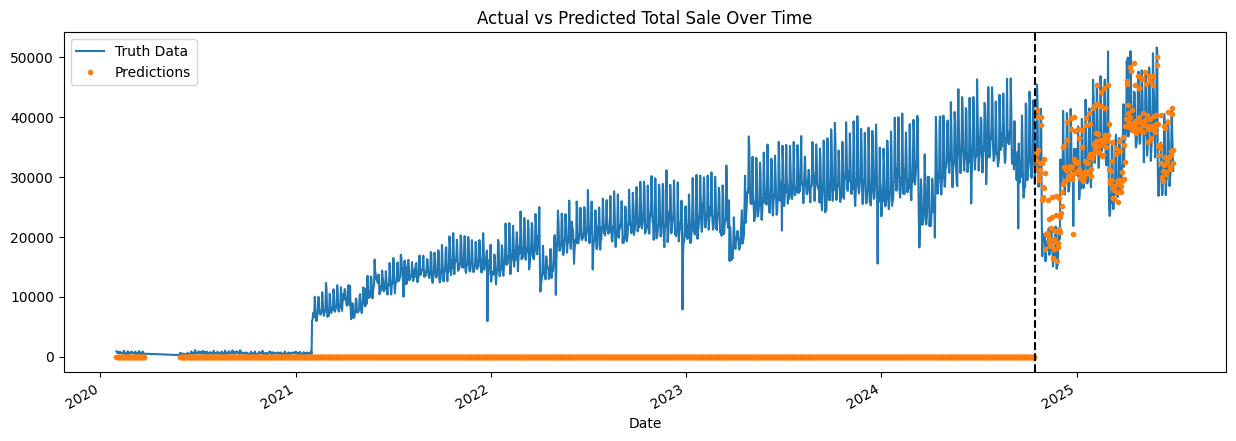

In [ ]:
test = test.copy()
test["prediction"] = baselines["GradientBoosting"].predict(X_test)

df_plot = df.merge(test[["prediction"]], how="left", left_index=True, right_index=True)

daily_actual = df_plot.groupby("Date")["Total Sale"].sum()
daily_pred = df_plot.groupby("Date")["prediction"].sum()

fig, ax = plt.subplots(figsize=(15, 5))
daily_actual.plot(ax=ax, label="Truth Data")
daily_pred.plot(ax=ax, style=".", label="Predictions")
ax.axvline(split_date, color="black", ls="--")
ax.legend(["Truth Data", "Predictions"])
ax.set_title("Actual vs Predicted Total Sale Over Time")
plt.show()


In [ ]:
import optuna

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=3)


def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 300, 800)
    max_depth = trial.suggest_int(
        "max_depth", 4, 20
    )  
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1,
    )

    score = cross_val_score(model, X_train, y_train, cv=tscv, scoring="r2").mean()
    return score


study2 = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study2.optimize(objective, n_trials=20)

print("Best params:", study2.best_params)
print("Best R²:", study2.best_value)


[I 2026-08-11 23:11:15,826] A new study created in memory with name: no-name-ecf1fd82-4ea1-44f9-a8c0-1815b4d1022e
[I 2026-08-11 23:12:49,639] Trial 0 finished with value: 0.8287600322214509 and parameters: {'n_estimators': 753, 'max_depth': 11, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.8287600322214509.
[I 2026-08-11 23:13:51,060] Trial 1 finished with value: 0.8271727039747829 and parameters: {'n_estimators': 622, 'max_depth': 8, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8287600322214509.
[I 2026-08-11 23:14:35,516] Trial 2 finished with value: 0.8243148158937402 and parameters: {'n_estimators': 500, 'max_depth': 7, 'min_samples_leaf': 18}. Best is trial 0 with value: 0.8287600322214509.
[I 2026-08-11 23:15:42,177] Trial 3 finished with value: 0.8269624976889532 and parameters: {'n_estimators': 544, 'max_depth': 19, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.8287600322214509.
[I 2026-08-11 23:16:39,597] Trial 4 finished with value: 0.828399453340662

Best params: {'n_estimators': 692, 'max_depth': 10, 'min_samples_leaf': 5}
Best R²: 0.8287636465090865


In [24]:
best_model = RandomForestRegressor(
    **study2.best_trial.params, random_state=42, n_jobs=-1
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)

test_mse = mean_squared_error(y_test, y_pred)

test_r2 = r2_score(y_test, y_pred)


print(f"Test MAE : {test_mae: .2f}")

print(f"Test MSE {test_mse: .2f}")

print(f"Test R2 Score :{test_r2:.2f}")


Test MAE :  151.95
Test MSE  60287.48
Test R2 Score :0.78


In [26]:
# For visualizations
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_slice,
    plot_contour,
    plot_param_importances,
)


In [27]:
# 1. Optimization History
plot_optimization_history(study2).show()


In [28]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study2).show()


In [29]:
# 3. Slice Plot
plot_slice(study2).show()


In [30]:
# 4. Contour Plot
plot_contour(study2).show()


In [31]:
# 5. Hyperparameter Importance
plot_param_importances(study2).show()


In [32]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42
)


xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_preds))
print("XGBoost MSE:", mean_squared_error(y_test, xgb_preds))
print("XGBoost R²:", r2_score(y_test, xgb_preds))


XGBoost MAE: 156.03089306460356
XGBoost MSE: 62313.42074746208
XGBoost R²: 0.775723042665083


In [33]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=20,
    min_child_samples=10,
    subsample=0.8,
    random_state=42,
)

lgbm_model.fit(X_train, y_train)
lgbm_preds = lgbm_model.predict(X_test)

print("LightGBM MAE:", mean_absolute_error(y_test, lgbm_preds))
print("LightGBM MSE:", mean_squared_error(y_test, lgbm_preds))
print("LightGBM R²:", r2_score(y_test, lgbm_preds))


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwar

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2308
[LightGBM] [Info] Number of data points in the train set: 44139, number of used features: 136
[LightGBM] [Info] Start training from score 703.429496
LightGBM MAE: 150.21617372394422
LightGBM MSE: 59142.10293127857
LightGBM R²: 0.7871371730726906


In [34]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    random_state=42,
    verbose=0,
)

cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)

print("CatBoost MAE:", mean_absolute_error(y_test, cat_preds))
print("CatBoost MSE:", mean_squared_error(y_test, cat_preds))
print("CatBoost R²:", r2_score(y_test, cat_preds))


CatBoost MAE: 150.24161269528156
CatBoost MSE: 58597.704338794065
CatBoost R²: 0.7890965593242439


In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=3)


def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 300, 800)
    max_depth = trial.suggest_int(
        "max_depth", 4, 10
    )
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    min_data_in_leaf = trial.suggest_int("min_data_in_leaf", 1, 20)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1.0, 10.0)

    model = CatBoostRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_data_in_leaf=min_data_in_leaf,
        l2_leaf_reg=l2_leaf_reg,
        random_state=42,
        thread_count=-1,
        verbose=0,
    )

    score = cross_val_score(model, X_train, y_train, cv=tscv, scoring="r2").mean()
    return score


study_cat = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler()
)
study_cat.optimize(objective, n_trials=20)

print("Best params:", study_cat.best_params)
print("Best CV R²:", study_cat.best_value)

# Train final model with best params
best_cat = CatBoostRegressor(
    **study_cat.best_params, random_state=42, thread_count=-1, verbose=0
)
best_cat.fit(X_train, y_train)

cat_test_preds = best_cat.predict(X_test)
from sklearn.metrics import r2_score

print("Test R² with tuned params:", r2_score(y_test, cat_test_preds))


[I 2026-08-11 23:35:09,400] A new study created in memory with name: no-name-62dd8811-e39a-421d-aca5-3a965f4baea4
[I 2026-08-11 23:35:44,440] Trial 0 finished with value: 0.8257946689996641 and parameters: {'n_estimators': 557, 'max_depth': 9, 'learning_rate': 0.034531637669409525, 'min_data_in_leaf': 13, 'l2_leaf_reg': 3.4165133657272997}. Best is trial 0 with value: 0.8257946689996641.
[I 2026-08-11 23:36:18,026] Trial 1 finished with value: 0.8307499650767287 and parameters: {'n_estimators': 772, 'max_depth': 8, 'learning_rate': 0.017352881869767668, 'min_data_in_leaf': 7, 'l2_leaf_reg': 1.6624252053308815}. Best is trial 1 with value: 0.8307499650767287.
[I 2026-08-11 23:37:06,596] Trial 2 finished with value: 0.8259563432781866 and parameters: {'n_estimators': 790, 'max_depth': 9, 'learning_rate': 0.02301139821569518, 'min_data_in_leaf': 1, 'l2_leaf_reg': 4.2158547067476775}. Best is trial 1 with value: 0.8307499650767287.
[I 2026-08-11 23:37:20,071] Trial 3 finished with value: 0

Best params: {'n_estimators': 456, 'max_depth': 4, 'learning_rate': 0.0709643665173755, 'min_data_in_leaf': 20, 'l2_leaf_reg': 9.644788278381204}
Best CV R²: 0.8404431679091814
Test R² with tuned params: 0.7909537663957034


In [36]:
best_cat = CatBoostRegressor(
    **study_cat.best_params, random_state=42, thread_count=-1, verbose=0
)
best_cat.fit(X_train, y_train)

cat_test_preds = best_cat.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Tuned CatBoost Test MAE:", mean_absolute_error(y_test, cat_test_preds))
print("Tuned CatBoost Test MSE:", mean_squared_error(y_test, cat_test_preds))
print(
    "Tuned CatBoost Test RMSE:",
)
print("Tuned CatBoost Test R²:", r2_score(y_test, cat_test_preds))


Tuned CatBoost Test MAE: 149.5222171012723
Tuned CatBoost Test MSE: 58081.695351360744
Tuned CatBoost Test RMSE:
Tuned CatBoost Test R²: 0.7909537663957034


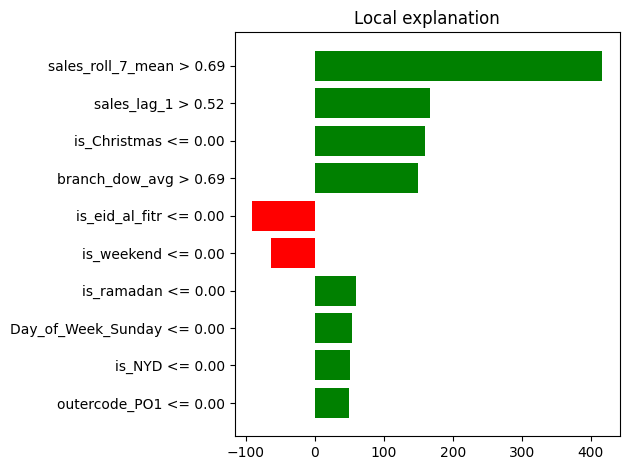


LIME explanation for test row 0:
  sales_roll_7_mean > 0.69: 416.985
  sales_lag_1 > 0.52: 167.065
  is_Christmas <= 0.00: 160.217
  branch_dow_avg > 0.69: 149.833
  is_eid_al_fitr <= 0.00: -90.635
  is_weekend <= 0.00: -63.409
  is_ramadan <= 0.00: 59.390
  Day_of_Week_Sunday <= 0.00: 53.649
  is_NYD <= 0.00: 51.588
  outercode_PO1 <= 0.00: 49.714


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode="regression",
    verbose=False,
)

sample_idx = 0  # change this to inspect a different row (e.g. a high-error branch)

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[sample_idx].values, best_cat.predict, num_features=10
)
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("lime_explanation_sample.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nLIME explanation for test row {sample_idx}:")
for feature, weight in lime_exp.as_list():
    print(f"  {feature}: {weight:.3f}")
